MARKOV ICL - REGRESSION
D=1, N=1, z_dim=2, nodes=8
Method: direct_solve
Regression head: linear (mlp_depth=2, mlp_width=16)
Device: cpu

Generating regression data...

Creating model...
  Initialized Markov ICL Regression model (N=1)
  Context/regression scorer: linear
  Parameters: 328

Training...
Epoch  10 | Train MSE: 0.354586 | Val MSE: 0.338521 | Val MAE: 0.315824
Epoch  20 | Train MSE: 0.169711 | Val MSE: 0.177809 | Val MAE: 0.187718
Epoch  30 | Train MSE: 0.125775 | Val MSE: 0.144678 | Val MAE: 0.173420
Epoch  40 | Train MSE: 0.098582 | Val MSE: 0.118006 | Val MAE: 0.143433
Epoch  50 | Train MSE: 0.085640 | Val MSE: 0.119635 | Val MAE: 0.138601
Epoch  60 | Train MSE: 0.078915 | Val MSE: 0.100003 | Val MAE: 0.144814
Epoch  70 | Train MSE: 0.072994 | Val MSE: 0.097887 | Val MAE: 0.126921
Epoch  80 | Train MSE: 0.069823 | Val MSE: 0.099181 | Val MAE: 0.154784
Epoch  90 | Train MSE: 0.064022 | Val MSE: 0.080270 | Val MAE: 0.123057
Epoch 100 | Train MSE: 0.060534 | Val MSE: 0.080014

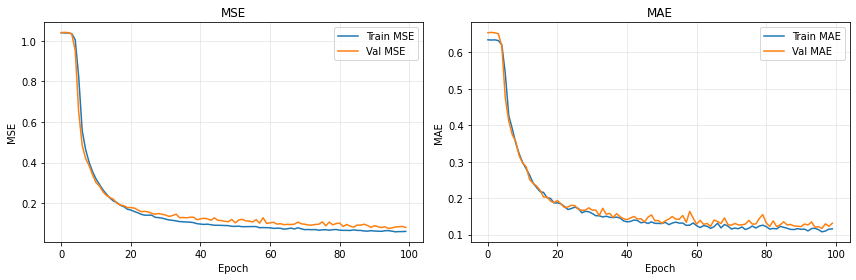


REGRESSION SUMMARY
Final Val MSE: 0.080014
Final Val MAE: 0.131155
Test MSE:      0.068823
Test MAE:      0.123759


In [ ]:
# Import from regression modules
import torch
import numpy as np
import time
from torch.utils.data import DataLoader

from data_generation_regression import generate_icl_regression_data
from datasets_regression import ICLRegressionDataset, collate_fn_regression
from models import MatrixTreeMarkovICLRegression, MLPICLRegression
from training_regression import train_model_regression, train_models_joint_regression
from evaluation_regression import test_regression

# ============================================================
# Data Parameters (Regression)
# ============================================================
D = 1                        # x-dimension
N = 1                        # number of context examples
noise_std = 0.0              # observation noise
task_scale = 1.0             # latent task weight scale
y_pad = 0.0                  # placeholder query y value
seed = 5

# ============================================================
# Model Parameters
# ============================================================
n_nodes = 8
z_dim = D + 1                # token is [x, y]
transform_func = "exp"
learn_base_rates = True
context_scorer_type = "linear"   # "linear" or "mlp" (Markov regression head)
mlp_depth = 2
mlp_width = 16

# Optional side-by-side MLP baseline
add_mlp = True
mlp_baseline_depth = 2
mlp_baseline_width = 64
mlp_baseline_dropout = 0.0
mlp_baseline_activation = "relu"

# ============================================================
# Sparsity Parameters
# ============================================================
sparsity_rho_edge = 1.0
sparsity_rho_all = 1.0
sparsity_rho_edge_base_W = 1.0
base_mask_value = float("-inf")

# ============================================================
# Training Parameters
# ============================================================
epochs = 100
lr = 0.01
batch_size = 100
train_samples = 5000
val_samples = 5000

# ============================================================
# Inference Parameters
# ============================================================
method = "direct_solve"

params = {
    "D": D,
    "N": N,
    "noise_std": noise_std,
    "task_scale": task_scale,
    "y_pad": y_pad,
    "seed": seed,
    "n_nodes": n_nodes,
    "z_dim": z_dim,
    "transform_func": transform_func,
    "learn_base_rates": learn_base_rates,
    "context_scorer_type": context_scorer_type,
    "mlp_depth": mlp_depth,
    "mlp_width": mlp_width,
    "add_mlp": add_mlp,
    "mlp_baseline_depth": mlp_baseline_depth,
    "mlp_baseline_width": mlp_baseline_width,
    "mlp_baseline_dropout": mlp_baseline_dropout,
    "mlp_baseline_activation": mlp_baseline_activation,
    "sparsity_rho_edge": sparsity_rho_edge,
    "sparsity_rho_all": sparsity_rho_all,
    "sparsity_rho_edge_base_W": sparsity_rho_edge_base_W,
    "base_mask_value": base_mask_value,
    "epochs": epochs,
    "lr": lr,
    "batch_size": batch_size,
    "train_samples": train_samples,
    "val_samples": val_samples,
    "method": method,
}

print("=" * 70)
print("MARKOV ICL - REGRESSION")
print("=" * 70)
print(f"D={D}, N={N}, z_dim={z_dim}, nodes={n_nodes}")
print(f"Method: {method}")
print(f"Markov regression head: {context_scorer_type} (mlp_depth={mlp_depth}, mlp_width={mlp_width})")
print(
    f"Baselines enabled: add_mlp={add_mlp} "
    f"(depth={mlp_baseline_depth}, width={mlp_baseline_width}, "
    f"dropout={mlp_baseline_dropout}, activation={mlp_baseline_activation})"
)
print("=" * 70)

torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# Generate data
print("Generating regression data...")
train_data = generate_icl_regression_data(
    n_samples=train_samples,
    N=N,
    D=D,
    noise_std=noise_std,
    task_scale=task_scale,
    y_pad=y_pad,
    seed=seed,
)
val_data = generate_icl_regression_data(
    n_samples=val_samples,
    N=N,
    D=D,
    noise_std=noise_std,
    task_scale=task_scale,
    y_pad=y_pad,
)

train_loader = DataLoader(
    ICLRegressionDataset(train_data),
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_regression,
)
val_loader = DataLoader(
    ICLRegressionDataset(val_data),
    batch_size=batch_size,
    collate_fn=collate_fn_regression,
)

# Create models
print("\nCreating model(s)...")
markov_model = MatrixTreeMarkovICLRegression(
    n_nodes=n_nodes,
    z_dim=z_dim,
    N=N,
    learn_base_rates=learn_base_rates,
    transform_func=transform_func,
    sparsity_rho_edge=sparsity_rho_edge,
    sparsity_rho_all=sparsity_rho_all,
    sparsity_rho_edge_base_W=sparsity_rho_edge_base_W,
    base_mask_value=base_mask_value,
    context_scorer_type=context_scorer_type,
    mlp_depth=mlp_depth,
    mlp_width=mlp_width,
)

models_to_train = {"markov": markov_model}
if add_mlp:
    models_to_train["mlp"] = MLPICLRegression(
        z_dim=z_dim,
        N=N,
        depth=mlp_baseline_depth,
        hidden_width=mlp_baseline_width,
        dropout=mlp_baseline_dropout,
        activation=mlp_baseline_activation,
    )

# Train
start_time = time.time()
print("\nTraining...")
print("=" * 70)

if add_mlp:
    history = train_models_joint_regression(
        models=models_to_train,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        n_epochs=epochs,
        lr=lr,
        method=method,
    )
else:
    history = train_model_regression(
        model=markov_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        n_epochs=epochs,
        lr=lr,
        method=method,
    )

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

# Test
if add_mlp:
    results = {}
    for name, model in models_to_train.items():
        torch.manual_seed(seed)
        np.random.seed(seed)
        results[name] = test_regression(
            model=model,
            N=N,
            D=D,
            device=device,
            n_samples=1000,
            noise_std=noise_std,
            task_scale=task_scale,
            y_pad=y_pad,
            method=method,
        )
else:
    results = test_regression(
        model=markov_model,
        N=N,
        D=D,
        device=device,
        n_samples=1000,
        noise_std=noise_std,
        task_scale=task_scale,
        y_pad=y_pad,
        method=method,
    )

# Optional plotting
try:
    import matplotlib.pyplot as plt

    if add_mlp:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(history["markov"]["train_mse"], label="Markov Train MSE")
        axes[0].plot(history["markov"]["val_mse"], label="Markov Val MSE")
        axes[0].plot(history["mlp"]["train_mse"], "--", label="MLP Train MSE")
        axes[0].plot(history["mlp"]["val_mse"], "--", label="MLP Val MSE")
        axes[0].set_title("MSE")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("MSE")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(history["markov"]["train_mae"], label="Markov Train MAE")
        axes[1].plot(history["markov"]["val_mae"], label="Markov Val MAE")
        axes[1].plot(history["mlp"]["train_mae"], "--", label="MLP Train MAE")
        axes[1].plot(history["mlp"]["val_mae"], "--", label="MLP Val MAE")
        axes[1].set_title("MAE")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 70)
        print("REGRESSION SUMMARY")
        print("=" * 70)
        print(f"Markov Final Val MSE: {history['markov']['val_mse'][-1]:.6f}")
        print(f"Markov Final Val MAE: {history['markov']['val_mae'][-1]:.6f}")
        print(f"Markov Test MSE:      {results['markov']['mse']:.6f}")
        print(f"Markov Test MAE:      {results['markov']['mae']:.6f}")
        print("-" * 70)
        print(f"MLP Final Val MSE:    {history['mlp']['val_mse'][-1]:.6f}")
        print(f"MLP Final Val MAE:    {history['mlp']['val_mae'][-1]:.6f}")
        print(f"MLP Test MSE:         {results['mlp']['mse']:.6f}")
        print(f"MLP Test MAE:         {results['mlp']['mae']:.6f}")
        print("=" * 70)

    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(history["train_mse"], label="Train MSE")
        axes[0].plot(history["val_mse"], label="Val MSE")
        axes[0].set_title("MSE")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("MSE")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(history["train_mae"], label="Train MAE")
        axes[1].plot(history["val_mae"], label="Val MAE")
        axes[1].set_title("MAE")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 70)
        print("REGRESSION SUMMARY")
        print("=" * 70)
        print(f"Final Val MSE: {history['val_mse'][-1]:.6f}")
        print(f"Final Val MAE: {history['val_mae'][-1]:.6f}")
        print(f"Test MSE:      {results['mse']:.6f}")
        print(f"Test MAE:      {results['mae']:.6f}")
        print("=" * 70)

except ImportError:
    print("\nInstall matplotlib for plots.")

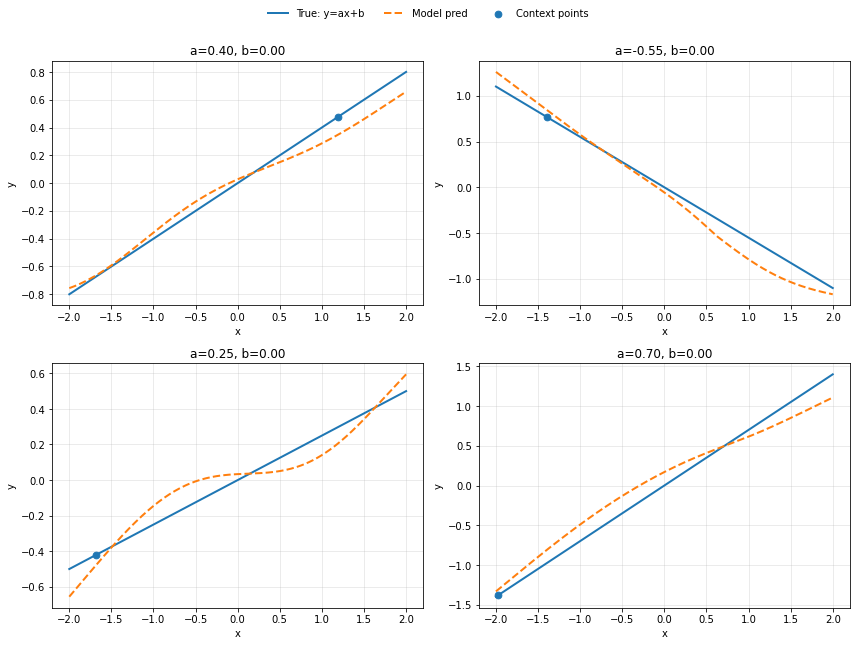

In [2]:
# ============================================================
# Linear-only in-context function visualization
# ============================================================
# Assumes you've already trained:
# - model
# - and defined: D, N, y_pad, method, device

import torch
import matplotlib.pyplot as plt

assert D == 1, "This plotting block assumes D=1 for curve visualization."

def make_linear_episode(a, b, N=4, x_range=(-2.0, 2.0), y_pad=0.0, query_grid_size=250):
    """
    Build one episode from y = a*x + b.
    Context tokens: [x_i, y_i]
    Query token:    [x_q, y_pad]
    """
    x_min, x_max = x_range

    # Context
    x_ctx = torch.empty(N, 1).uniform_(x_min, x_max)
    y_ctx = a * x_ctx.squeeze(1) + b

    # Query grid
    xq = torch.linspace(x_min, x_max, query_grid_size).unsqueeze(1)
    y_true = a * xq.squeeze(1) + b

    # Build batched z_seq over all query x values
    z_context = torch.cat([x_ctx, y_ctx.unsqueeze(1)], dim=1)  # (N, 2)
    z_batch = []
    for i in range(query_grid_size):
        z_query = torch.tensor([xq[i, 0].item(), y_pad], dtype=z_context.dtype)
        z_seq = torch.cat([z_context, z_query.unsqueeze(0)], dim=0)  # (N+1, 2)
        z_batch.append(z_seq)
    z_batch = torch.stack(z_batch, dim=0)  # (Q, N+1, 2)

    return x_ctx.squeeze(1), y_ctx, xq.squeeze(1), y_true, z_batch


@torch.no_grad()
def predict_curve(model, z_batch, device, method="direct_solve"):
    model.eval()
    return model(z_batch.to(device), method=method).cpu()


# Choose a few linear tasks to probe
linear_tasks = [
    (0.8, 0),
    (-1.1, 0),
    (0.5, 0),
    (1.4, -0),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (a, b) in zip(axes, linear_tasks):
    fac = 0.5
    a = fac * a
    x_ctx, y_ctx, xq, y_true, z_batch = make_linear_episode(
        a= a, b=b, N=N, x_range=(-2, 2), y_pad=y_pad, query_grid_size=250
    )
    y_pred = predict_curve(model, z_batch, device=device, method=method)

    ax.plot(xq.numpy(), y_true.numpy(), lw=2, label="True: y=ax+b")
    ax.plot(xq.numpy(), y_pred.numpy(), "--", lw=2, label="Model pred")
    ax.scatter(x_ctx.numpy(), y_ctx.numpy(), s=45, zorder=3, label="Context points")
    ax.set_title(f"a={a:.2f}, b={b:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Grid
x = np.linspace(-2, 2, 40)
y = np.linspace(-2, 2, 40)
z = np.linspace(-2, 2, 40)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

# Original form with singularity mask
eps = 1e-2
F = np.full_like(X, np.nan, dtype=float)
mask = np.abs(Z) > eps
F[mask] = Z[mask] * (Y[mask] / X[mask])  # equals Y where defined

# Isosurface of f over 3D domain
fig = go.Figure(data=go.Isosurface(
    x=X.ravel(), y=Y.ravel(), z=Z.ravel(),
    value=np.nan_to_num(F, nan=0.0).ravel(),
    isomin=-1.5, isomax=1.5, surface_count=6,
    caps=dict(x_show=False, y_show=False, z_show=False)
))
fig.update_layout(title="f = z*(y/x) over 3D domain")
fig.show()